# **Regressão Linear e Logística**
<font size=3>

Vamos explorar dois dos modelos mais fundamentais do aprendizado de máquina supervisionado: **Regressão Linear** e **Regressão Logística**. Ambos servem como porta de entrada para compreender como algoritmos aprendem padrões a partir de dados e fazem previsões em novos cenários. A regressão linear será usada para resolver problemas em que a saída é **contínua**, enquanto a regressão logística será aplicada em tarefas de **classificação**. Por meio destas abordagens, analisaremos conceitos fundamentais como **underfitting** e **overfitting**, preparando a base metodológica para modelos mais complexos.


## **1. Introdução:**
<font size=3>

Grande parte dos problemas em **aprendizado de máquina** (*supervisionado*) pode ser organizada em duas categorias principais:

<font size=3>

* **Regressão** busca **prever valores numéricos** contínuos.
  - A saída pode assumir **qualquer valor real**.
  - Por exemplo:
    - Prever o **preço de uma casa** em função do tamanho, localização e número de quartos.
    - Estimar o **consumo de energia elétrica** de uma residência ao longo do mês.

<br>

* **Classificação** busca **atribuir uma categoria** a uma observação.
  - A saída é **um rótulo discreto** (duas ou mais classes possíveis).
  - Por exemplo:
    - Determinar se um e-mail é **spam ou não spam**.
    - Classificar se um **tumor** é **maligno ou benigno** a partir de características médicas.


<font size=3><center>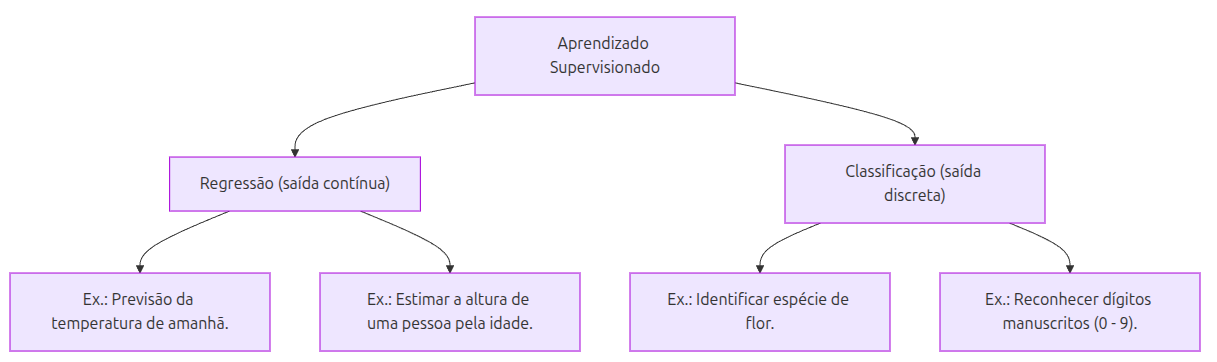</center>

### **1.1 Modelos fundamentais:**
<font size=3>
    
Iremos estudar, a seguir, os modelos *fundamentais* para as tarefas de *regressão* (**regressão linear**) e *classificação* (**regressão logística**). Apesar de simples, esses modelos são essenciais para a compreensão didática desses tipos de tarefas e possuem uma formulação matemática acessível. Eles servirão como porta de entrada para conceitos mais avançados e também nos permitirão explorar fenômenos importantes, como o **_underfitting_** e o **_overfitting_**, comuns em modelos de aprendizado de máquina.

> **Atenção ao nome dos modelos!** Apesar de se chamar regressão logística, este modelo é usado para classificação. O termo “regressão” aparece porque ele estima uma função matemática contínua, mas sua finalidade é atribuir a classe mais provável a cada amostra.


### **1.2 Fluxo de trabalho em AM:**
<font size=3>
    
O desenvolvimento de um modelo em AM geralmente segue um **fluxo de etapas**:
1. **Importar e explorar os dados** — entender suas características, distribuições e possíveis problemas.
2. **Pré-processar os dados** — tratar valores ausentes, normalizar/transformar atributos e preparar as variáveis de entrada.
3. **Treinar o modelo** — escolha de um modelo e ajuste dos parâmetros internos a partir dos dados de treino.
4. **Realizar predições** — aplicar o modelo treinado em novos dados.
5. **Avaliar o desempenho** — medir acurácia, erro ou outras métricas adequadas ao problema.

## **2. Regressão Linear:**
<font size=3>

A **regressão linear** é um modelo supervisionado usado para problemas de **regressão**, isto é, quando queremos prever uma **variável numérica contínua** a partir dos atributos $x_i$ da entrada de uma amostra.

### **2.1 Formulação matemática:**
<font size=3>

O modelo assume que a saída $y$ pode ser aproximada por uma combinação linear das entradas:
$$
    \hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_n x_n \, ,
$$
onde $n$ é o número de atributos e $w_i$, tal que $i \in [0,\,n]$, são os coeficientes da função (**parâmetros internos do modelo**).

O objetivo do **treinamento** deste modelo é encontrar os **parâmetros $w$** que minimizam o erro entre os valores previstos $\hat{y}$ e os valores reais $y$. A função de custo/perda mais usada é o **Erro Quadrático Médio (MSE)**:
$$
    \mathcal{L}(w) = \frac{1}{m} \sum_{i=1}^{m} \big( y^{(i)} - \hat{y}^{(i)} \big)^2 \, .
$$

### **2.2 Ajustes do parâmetros do modelo:**
<font size=3>

Para a fase de treinamento deste modelo, existem diferentes maneiras de ajustar os parâmetros:

1. **Mínimos Quadrados Ordinários (OLS):** resolve o problema via Álgebra Linear,
$$
    \mathbf{\hat{w}} = (\mathbf{x}^T\cdot\mathbf{x})^{-1}\,\mathbf{x}^T\cdot \mathbf{y} \, .
$$

2. **Gradiente Descendente:** método **iterativo** que ajusta os parâmetros gradualmente para minimizar o erro.

<br>

> **Observação:** em aprendizado de máquina, é comum encontrar os termos **_"treinar o modelo"_** e **_"fitar o modelo"_** como equivalentes. Ambos se referem ao processo de ajustar os parâmetros internos do modelo a partir dos dados de treinamento.


### **2.3 Exemplo prático:**
<font size=3>

Neste curso, utilizaremos o $\texttt{sklearn}$ (**scikit-learn**) como biblioteca padrão para importar os modelos clássicos de aprendizado de máquina.

Abaixo, segue um exemplo de regressão, desenvolvido com dados sintéticos — via a função [`make_regression`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_regression.html) — para fins didáticos, solucionado com o modelo [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).

Utilizaremos também a função [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) para dividir os dados simulados entre:
 - **treinamento** — amostragem dos dados ($\sim 70\%$) utilizada *unicamente* para o treinamento do modelo;
 - **teste** — amostragem dos dados ($\sim 30\%$) utilizada para realizar **previsões** e **avaliação do desempenho** do modelo.
   
> **Analogia:** o professor desenvolveu 100 questões para seus alunos. A maior parte destas questões (70 delas) serão utilizadas como listas de exercícios (treinamento), e as restantes irão compor a prova (avaliação da performance).   

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression #os dados para o modelo
from sklearn.model_selection import train_test_split #para treino e test
from sklearn.linear_model import LinearRegression #o modelo propriamente dito

In [2]:
# gerando dados sintéticos para exemplo de regressão:
X, y = make_regression(n_samples=100,    # número de amostras
                       n_features=1,     # número de atributos
                       noise=15,         # ruído
                       random_state=42)  # valor da semente para a geração de números aleatórios

# dividindo os dados entre treinamento e teste:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X-train:{X_train.shape}, y-train:{y_train.shape}")
print(f"X-test:{X_test.shape}, y-test:{y_test.shape}")

X-train:(70, 1), y-train:(70,)
X-test:(30, 1), y-test:(30,)


<font size=3>

> **Observação:**  na **regressão linear**, a etapa de **normalização dos dados não é estritamente necessária** porque a solução analítica encontra os coeficientes de forma exata, independentemente da escala das variáveis.


In [3]:
# definindo o modelo de regressão:
model = LinearRegression()

# fitando os dados de treinamento:
model.fit(X_train, y_train)

# previsão do modelo:
y_pred = model.predict(X_test)

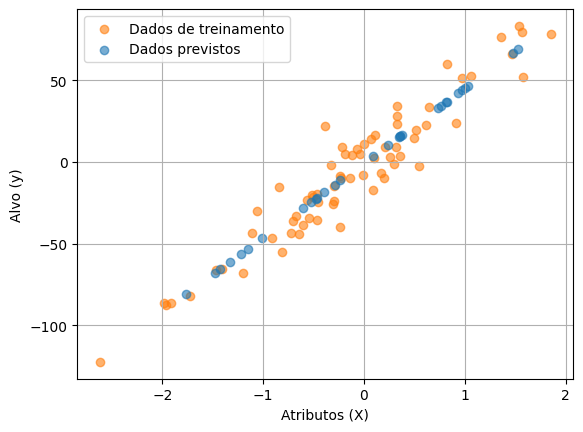

Coeficiente (w1): 45.632
Intercepto (w0): -0.545


In [4]:
plt.scatter(X_train, y_train, color="tab:orange", alpha=0.6, label="Dados de treinamento")
plt.scatter(X_test, y_pred, color="tab:blue", alpha=0.6, label="Dados previstos")
plt.xlabel("Atributos (X)")
plt.ylabel("Alvo (y)")
plt.legend()
plt.grid()
plt.show()

print(f"Coeficiente (w1): {model.coef_[0]:.3f}")
print(f"Intercepto (w0): {model.intercept_:.3f}")

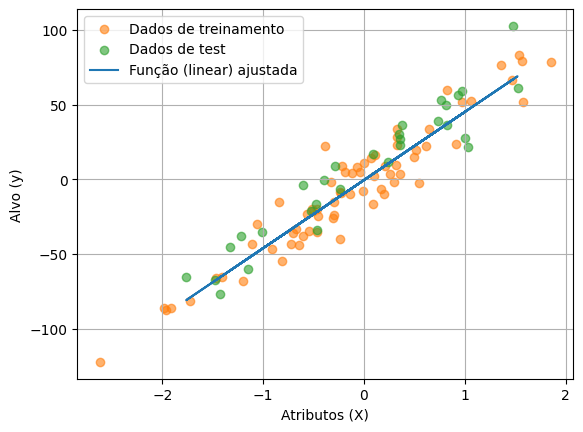

In [5]:
plt.scatter(X_train, y_train, color="tab:orange", alpha=0.6, label="Dados de treinamento")
plt.scatter(X_test, y_test, color="tab:green", alpha=0.6, label="Dados de test")
plt.plot(X_test, y_pred, color="tab:blue", lw=1.5, label="Função (linear) ajustada")
plt.xlabel("Atributos (X)")
plt.ylabel("Alvo (y)")
plt.legend()
plt.grid()
plt.show()

<font size=3>

Para medirmos o **desempenho do modelo**, vamos usar a métrica [mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html).

In [6]:
from sklearn.metrics import mean_squared_error

# avaliação do modelo:
mse = mean_squared_error(y_test, y_pred)

print(f"MSE: {mse:.2f}")

MSE: 232.81


### **2.4 Interpolação vs extrapolação**:
<font size=3>

Quando usamos um modelo de regressão linear para prever valores, é importante diferenciar duas situações:

- **Interpolação:**
    * Ocorre quando fazemos previsões **dentro do intervalo** dos dados usados no treinamento.
    * A interpolação costuma ser **confiável**, já que o modelo aprendeu padrões nesse intervalo.
    * Por exemplo, se treinamos um modelo com dados de **idades entre 10 e 18 anos** e queremos prever a altura de uma pessoa de **15 anos**, estamos interpolando.
      
<br>

- **Extrapolação:**
    * Ocorre quando fazemos previsões **fora do intervalo** dos dados de treinamento.
    * A extrapolação pode ser **arriscada**, pois o modelo está assumindo que o mesmo padrão linear se mantém fora da faixa observada — o que nem sempre é verdadeiro.
    * Por exemplo, usar o mesmo modelo (treinado com idades entre 10 e 18) para prever a altura de uma pessoa de **30 anos**.


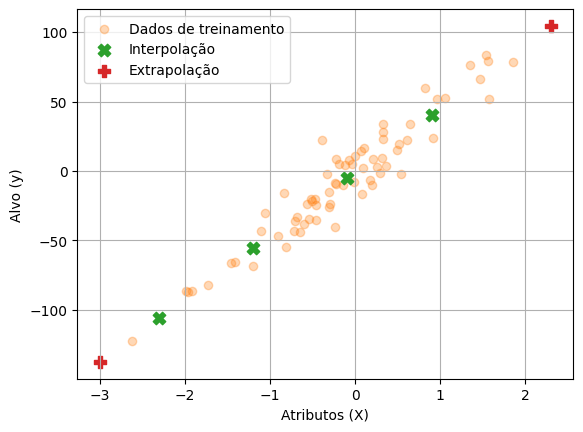

In [ ]:
# simulando dados para interpolação:
X_inter = np.array([[-2.3], [-1.2], [-0.1], [0.9]])

# simulando dados para extrapolação:
X_extra = np.array([[-3.0], [2.3]])

# realizando previsões:
y_inter = model.predict(X_inter)
y_extra = model.predict(X_extra)


plt.scatter(X_train, y_train, color="tab:orange", alpha=0.3, label="Dados de treinamento")
plt.scatter(X_inter, y_inter, color="tab:green", s=80, marker="X", label="Interpolação")
plt.scatter(X_extra, y_extra, color="tab:red", s=80, marker="P", label="Extrapolação")
plt.xlabel("Atributos (X)")
plt.ylabel("Alvo (y)")
plt.legend()
plt.grid()
plt.show()

## **3. Regressão Logística:**
<font size=3>

A **regressão linear** (*seção anterior*) funciona bem para prever valores **contínuos**, mas **não** é adequada quando a saída desejada é **categórica**, como em tarefas de classificação:

<font size=3>

* "E-mail é spam ou não spam?"
* "Paciente tem doença ou não?"
* "A flor pertence à espécie setosa, versicolor ou virginica?"

Nesses casos, precisamos de um modelo que **produza probabilidades** associadas a classes. É aí que entra a **regressão logística**.

### **3.1 Formulação matemática:**
<font size=3>

O modelo parte de uma combinação linear das entradas (assim como na regressão linear):
$$
    z = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_n x_n \, .
$$

Em vez de usar $z$ diretamente, aplicamos a **função sigmoide (logística)** para mapear o resultado para o intervalo $[0, 1]$,
$$
    \sigma(z) = \frac{1}{1 + e^{-z}} \, .
$$

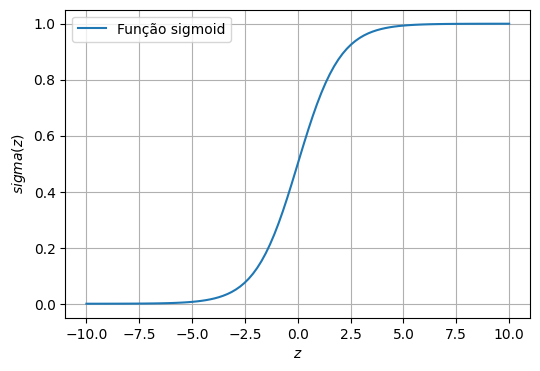

In [7]:
z = np.linspace(-10, 10, 100)
σ = 1/(1 + np.exp(-z))

plt.figure(figsize=(6,4))
plt.plot(z, σ, label="Função sigmoid")
plt.ylabel(r"$sigma(z)$")
plt.xlabel("$z$")
plt.legend()
plt.grid()
plt.show()

<font size=3>

Assim, a previsão do modelo é dada pela **probabilidade** de $y=1$ dado $\mathbf{x}$,
$$
    \hat{y} = P(y=1 \mid x) = \sigma(z) \, ,
$$
tal que,
 - se $\hat{y} \geq 0.5$, classificamos como **classe 1**;
 - se $\hat{y} < 0.5$, classificamos como **classe 0**.
   

#### **3.1.1 Classificação multiclasse:**
<font size=3>  

Para problemas com mais de duas classes ($K$ classes), a regressão logística utiliza a função **softmax**, que transforma os escores lineares $z_k = \mathbf{w}_k^T \mathbf{x}$ em probabilidades normalizadas,
$$
    P(y=k \mid x) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}, \quad k \in [1,\,K] \, ,
$$
o que garante que as probabilidades somem 1, permitindo escolher a classe com maior valor.

**Por exemplo:** suponha que o modelo calcule os escores $z = [2.0,\; 1.0,\; 0.1]$. Aplicando a softmax, obtemos:
$$
    \text{Softmax}(z) \approx [0.66,\; 0.24,\; 0.10] \, ,
$$

ou seja, o modelo atribui 66% à **classe 1**, 24% à **classe 2** e 10% à **classe 3** — assim, a predição final seria a **classe 1**.

#### **3.1.2 Métrica de avaliação:**
<font size=3>

Para avaliarmos uma predição categórica, podemos utilizar a métrica **acurácia** — ela indica a fração de vezes em que o modelo acertou a classe correta:
$$
    \text{Acurácia} = \frac{\text{Número de acertos}}{\text{Total de exemplos}} \in [0,\, 1] \, .
$$


### **3.2 Exemplo prático:**
<font size=3>

Para ilustrar uma tarefa de classificação, iremos simular os dados com a função [`make_classification`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html) e utilizar o modelo [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), que é robusto ao número de classes. A avaliação será dada pela medição da função [`accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html).


In [8]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
# gerando dados sintéticos para exemplo de classsificação:
X, y = make_classification(n_samples=600,          # número de amostras
                           n_features=2,           # número de atributos
                           n_informative=2,        # número de atributos que são informativos
                           n_redundant=0,          # número de atributos redundantes
                           n_clusters_per_class=1, # número de grupos de amostras por classe
                           random_state=2) #seed

# dividindo os dados entre treinamento e teste:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

<font size=3>

Na **regressão logística**, a normalização dos dados **não é obrigatória para que o modelo funcione**, mas é **altamente recomendada**. Isso porque os parâmetros são estimados por **métodos iterativos de otimização** (como gradiente), e variáveis em escalas muito diferentes podem tornar o processo de convergência mais lento ou até instável. Assim, faremos a normalização dos dados com a função [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

In [10]:
from sklearn.preprocessing import StandardScaler

# normalização dos dados:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fita (calcula a média e desvio padrão) e transforma (normaliza) X-train
X_test = scaler.transform(X_test)        # só transforma X-test

print(f"X-train:{X_train.shape}, y-train:{y_train.shape}")
print(f"X-test:{X_test.shape}, y-test:{y_test.shape}")

X-train:(420, 2), y-train:(420,)
X-test:(180, 2), y-test:(180,)


In [11]:
# definindo o modelo de classificação:
model = LogisticRegression(max_iter=2000) # número máximo de iteração para convergir

# fitando o modelo com dados de treinamento:
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [12]:
# previsão e avaliação do modelo:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print(f"Acurácia: {acc:.2f}")

Acurácia: 0.86


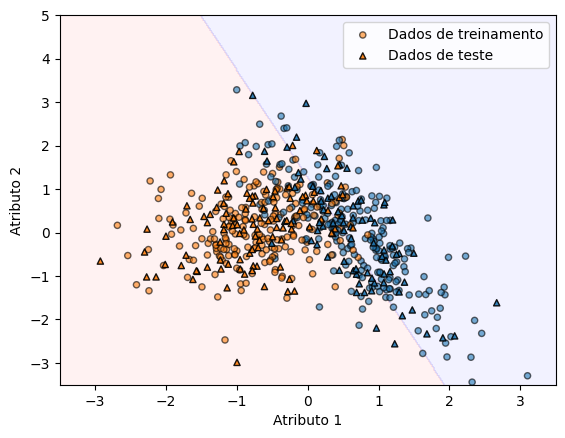

In [13]:
from matplotlib.colors import ListedColormap

# para visualizarmos a fronteira de classificação, iremos criar um grid (grade)
# com uma distribuição homogênea de pontos de ambos os atributos:

atrib1, atrib2 = np.meshgrid(np.linspace(-3.5, 3.5, 300),
                             np.linspace(-3.5, 5.0, 300))

grid = np.c_[atrib1.ravel(), atrib2.ravel()]

# normalizando o grid com a mesma média e desvio padrão que fitou os dados de treinamento:
grid = scaler.transform(grid)

# fazendo a predição do grid para visualizarmos a fronteira de classificação:
Z = model.predict(grid).reshape(atrib1.shape)


cmap_fundo = ListedColormap(["#FFCCCC", "#CCCCFF"])
cmap_pontos = ListedColormap(["tab:orange", "tab:blue"])

plt.contourf(atrib1, a Ztrib2,, alpha=0.25, cmap=cmap_fundo)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_pontos,
            s=20, edgecolor="k", alpha=0.6, label="Dados de treinamento")

plt.scatter(X_test[:, 0],  X_test[:, 1], c=y_test, cmap=cmap_pontos,
            s=20, marker="^", edgecolor="k", alpha=0.9, label="Dados de teste")

plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.legend()
plt.show()

<font size=3>

**Observe que** a visualização da fronteira de classificação com os atributos desse *dataset* só foi possível, porque simulamos dados com apenas **dois** atributos. Para uma visualização semelhante de um *dataset* com mais atributos, precisaremos realizar o **PCA** antes do *plot* e considerar as duas primeiras **componentes principais** como eixos do gráfico!

#### **3.2.1 Estimadores do $\text{scikit-learn}$:**
<font size=3>

Na biblioteca `scikit-learn`, os métodos `fit()`, `transform()` e `fit_transform()` acompanham os **objetos** denominados **"estimadores"**, que formam a base para a maioria dos algoritmos e transformações de dados na biblioteca. Estes métodos permitem que diferentes etapas de um projeto de aprendizado de máquina, como pré-processamento, extração de características e modelagem, sejam encadeadas de forma coesa e intercambiável.

  - O método `fit()` analisa os dados fornecidos como argumento e calcula os **parâmetros internos** necessários para a sua operação. Por exemplo:
      * Em um objeto `StandardScaler`, o `fit()` calculará a média ($\mu$) e o desvio padrão ($\sigma$) de cada característica nos dados de treinamento.
      * Em um objeto `PCA` (Análise de Componentes Principais), o `fit()` irá calcular as componentes principais (os eixos de maior variância) a partir dos dados.

<br>

  - Uma vez que o estimador tenha sido *"treinado"* com o método `fit()`, o método `transform()` pode ser utilizado para **aplicar a transformação *"aprendida"*** aos dados. Ele utiliza os parâmetros internos calculados pelo `fit()` para modificar os dados de entrada.
      * Para o `StandardScaler`, o `transform()` calcula $x' = (x-\mu)/\sigma$ para cada ponto de dado.
      * Para o `PCA` (Análise de Componentes Principais), o `transform()` irá projetar os dados nas componentes principais aprendidos, reduzindo sua dimensionalidade.

<br>

  - O método `fit_transform()` é, em essência, uma **combinação conveniente e otimizada** dos métodos `fit()` e `transform()` executados em sequência nos mesmos dados. Ele primeiro chama o `fit()` para ajustar os parâmetros internos com os dados e, em seguida, chama o `transform()` para aplicar a transformação a esses mesmos dados.

Agora, vamos considerar essas operações do `StandardScaler` com dados de **treinamento** e **teste** — normalização para que os atributos **tenham média 0** e **desvio padrão 1**.

> 1.  `scaler = StandardScaler()`: definição do estimador (`scaler`).

> 2.  `X_train = scaler.fit_transform(X_train)`:

>   - O estimador calcula (`fit()`) a média $\mu_{treino}$ e o desvio padrão $\sigma_{treino}$ dos dados de treinamento (`X_train`) e os armazena.
>   - Em seguida, aplica a transformação $x' = (x - \mu_{treino}) / \sigma_{treino}$ (`transform()`) nos dados de treino.

> 3.  `X_test = scaler.transform(X_test)`: com os parâmetros $\mu_{treino}$ e $\sigma_{treino}$ já previamente calculados, o estimador aplica a transformação (`transform()`) nos dados de teste. Apenas transformar os dados de teste garante que o modelo seja avaliado por dados que são tratados de forma consistente, como se fossem informações novas, o que proporciona uma avaliação justa e realista do seu desempenho.

Já no caso de modelos de aprendizado de máquina, como `model = LinearRegression()`, utilizamos `model.fit(X_train, y_train)` para ajustar os parâmetros internos ($\omega_n$) do modelo, e `model.predict(X_test)` para aplicar a função linear $\hat y = \sum_{n=0}^N \omega_n\,x^n\,$.

## **4. _Underfitting_ vs _Overfitting_**
<font size=3>

Ao treinar modelos de aprendizado de máquina, é comum enfrentar dois comportamentos indesejados — **_underfitting_** e **_overfitting_** — que surgem de um **desajuste entre a complexidade do modelo e os dados disponíveis**.

<font size=3>

* **Underfitting (subajuste)**: o modelo é **simples demais** para capturar o padrão dos dados $\rightarrow$ alto erro **de treino** e **de teste**.
* **Overfitting (sobreajuste)**: o modelo é **complexo demais**, “decora” o ruído do treino $\rightarrow$ erro de treino **baixo** e erro de teste **alto**.
* **Ajuste adequado**: complexidade suficiente para capturar o padrão sem se prender ao ruído $\rightarrow$ bons erros de treino **e** teste.

> **Analogia:** O aluno não aprendeu direito a lista de exercícios e, na prova, obteve mau desempenho (*underfitting*). O aluno "decorou" a lista, mas ao se deparar com questões diferentes na prova, não soube resolvê-las (*overfitting*). Já o aluno que compreendeu os conceitos, fez a lista e se deu bem na prova (*ajuste adequado*), mostrando boa **generalização**.

In [14]:
from sklearn.preprocessing import PolynomialFeatures

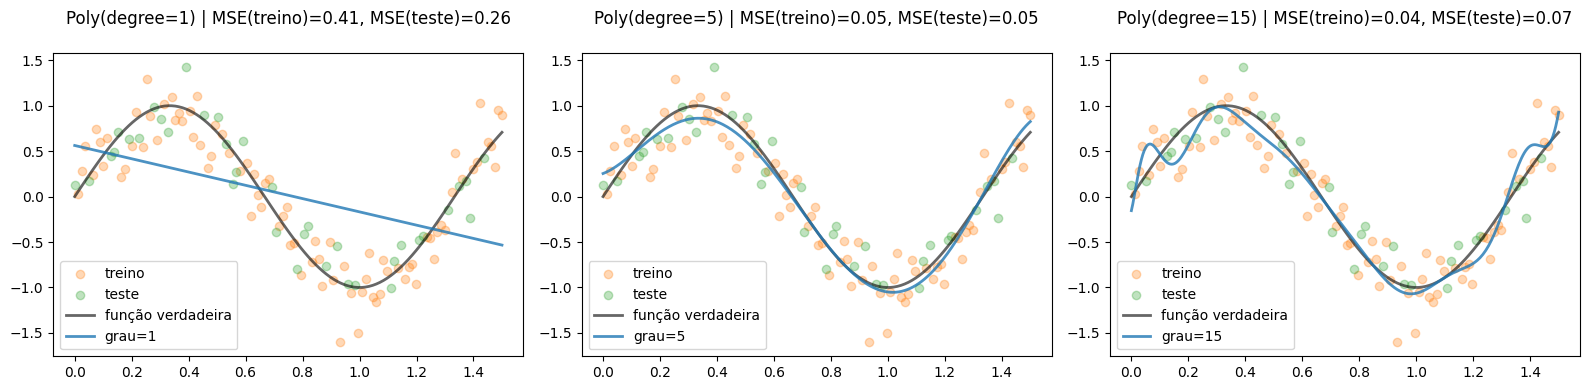

In [15]:
# simulando os dados:
rng = np.random.RandomState(42)

X = np.linspace(0, 1.5, 120)[:, None]
y_true = np.sin(1.5*np.pi*X).ravel()

y = y_true + rng.normal(0, 0.25, size=X.shape[0])

# dividindo os dados entre treinamento e teste:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)


def fit_and_plot(degree, ax):

    # transformação polinomial explícita:
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly  = poly.transform(X_test)

    # modelo de regressão linear:
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Métricas
    y_pred_train = model.predict(X_train_poly)
    y_pred_test  = model.predict(X_test_poly)

    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test,  y_pred_test)

    # curva fitada:
    fit_x = np.linspace(0, 1.5, 300)[:, None]
    poly_x = poly.transform(fit_x)
    fit_y = model.predict(poly_x)

    ax.set_title(f"Poly(degree={degree}) | MSE(treino)={mse_train:.2f}, MSE(teste)={mse_test:.2f}\n")
    ax.scatter(X_train, y_train, c="tab:orange", alpha=0.3, label="treino")
    ax.scatter(X_test,  y_test,  c="tab:green", alpha=0.3, label="teste")
    ax.plot(X, y_true, lw=2, c="black", alpha=0.6, label="função verdadeira")
    ax.plot(fit_x, fit_y, c="tab:blue", alpha=0.8, lw=2, label=f"grau={degree}")
    ax.legend()

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
fit_and_plot(1,  axs[0])   # underfitting
fit_and_plot(5,  axs[1])   # bom ajuste
fit_and_plot(15, axs[2])   # overfitting
plt.tight_layout()
plt.show()

<font size=3>
    
* **Grau 1**: reta não acompanha a curvatura $\rightarrow$ MSE alto em treino e teste (**underfitting**).
* **Grau 5**: acompanha a tendência sem ondulações excessivas $\rightarrow$ erros equilibrados (**ajuste adequado**).
* **Grau 15**: curva "serpenteia" os pontos de treino, mas piora no teste (**overfitting**).


### **4.1 Regressão Polinomial:**
<font size=3>
    
A **regressão linear simples** ajusta apenas uma **reta** (grau 1). Isso é suficiente para padrões lineares, mas limita quando os dados têm comportamento **curvo ou oscilatório**. A solução é a **regressão polinomial**, que nada mais é do que **criar novas features** a partir de potências da variável original:

$$
y \approx w_0 + w_1 x + w_2 x^2 + \dots + w_d x^d
$$

* Se $d=1$ → regressão linear clássica.
* Se $d=2$ → o modelo pode capturar **parábolas**.
* Se $d=3$ → consegue aprender **curvas mais complexas**.
* Graus muito altos ($d \gg 1$) podem levar ao **overfitting**.


## **5. Conceitos importantes:**
<font size=3>

Confira se você aprendeu os conceitos fundamentais de Aprendizado de Máquina:

- **Regressão** *vs* **Classificação**;
- Dados de **treinamento** *vs* **teste**.
- **Fit/treinamento do modelo**;
- **Interpolação** *vs* **Extrapolação**;
- **Underfitting** *vs* **Overfitting**;
- **Fluxo de trabalho** do aprendizado de máquina.
  

## __Referências:__
<font size=3>

- **(13.0-13.5; 16.0-16.5):** Gallatin, K. and Albon, C. *Machine Learning with Python Cookbook*, 2nd ed, 2023.
  